# Severity Analysis of Disaster Events

This notebook analyzes the severity and impact of disaster events including:
- Impact magnitude analysis (deaths, affected population, economic losses)
- Severity classification
- Extreme event identification
- Impact distribution analysis
- Comparative severity across hazard types

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from config import PROCESSED_DATA_DIR, FIGURES_DIR, HAZARD_TYPES
from src.risk_metrics import calculate_severity_index, classify_event_severity
from src.visualization import plot_severity_distribution, plot_impact_comparison

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Processed Data

In [2]:
data_file = PROCESSED_DATA_DIR / 'disaster_events_processed.csv'

if data_file.exists():
    df = pd.read_csv(data_file)
    print(f"Loaded {len(df)} processed records")
    print(f"\nColumns available: {df.columns.tolist()}")
    print(f"\nImpact columns:")
    impact_cols = [col for col in df.columns if 'death' in col.lower() or 'affected' in col.lower() or 'damage' in col.lower()]
    print(impact_cols)
else:
    print(f"Processed data not found. Please run notebook 01 first.")
    df = None

Loaded 30 processed records

Columns available: ['serial', 'glide', 'year', 'month', 'day', 'eventname', 'level1', 'level2', 'level3', 'latitude', 'longitude', 'hazardtype', 'deaths', 'injured', 'missing', 'affected', 'displaced', 'housesdestroyed', 'housesdamaged', 'educationcenters', 'healthcenters', 'localvalue', 'usdvalue', 'durationdays', 'eventdescription', 'date', 'season', 'total_affected', 'total_deaths', 'total_houses_affected', 'has_economic_data', 'has_coordinates']

Impact columns:
['deaths', 'affected', 'housesdamaged', 'total_affected', 'total_deaths', 'total_houses_affected']


## 2. Impact Magnitude Analysis

In [3]:
if df is not None:
    print("Impact Statistics Summary")
    print("="*60)
    
    if 'total_deaths' in df.columns:
        print("\n📊 Deaths:")
        print(f"  Total: {df['total_deaths'].sum():,.0f}")
        print(f"  Mean per event: {df['total_deaths'].mean():.1f}")
        print(f"  Median: {df['total_deaths'].median():.0f}")
        print(f"  Max (single event): {df['total_deaths'].max():,.0f}")
    
    if 'total_affected' in df.columns:
        print("\n👥 People Affected:")
        print(f"  Total: {df['total_affected'].sum():,.0f}")
        print(f"  Mean per event: {df['total_affected'].mean():,.0f}")
        print(f"  Median: {df['total_affected'].median():,.0f}")
        print(f"  Max (single event): {df['total_affected'].max():,.0f}")
    
    if 'total_damage' in df.columns:
        print("\n💰 Economic Damage (USD):")
        print(f"  Total: ${df['total_damage'].sum():,.0f}")
        print(f"  Mean per event: ${df['total_damage'].mean():,.0f}")
        print(f"  Median: ${df['total_damage'].median():,.0f}")
        print(f"  Max (single event): ${df['total_damage'].max():,.0f}")

Impact Statistics Summary

📊 Deaths:
  Total: 11,887
  Mean per event: 396.2
  Median: 120
  Max (single event): 4,120

👥 People Affected:
  Total: 11,682,109
  Mean per event: 389,404
  Median: 201,290
  Max (single event): 1,553,900


## 3. Severity Classification

Severity Classification Results:

Events by Severity Level:
  Minor: 0 (0.0%)
  Moderate: 30 (100.0%)
  Severe: 0 (0.0%)
  Catastrophic: 0 (0.0%)


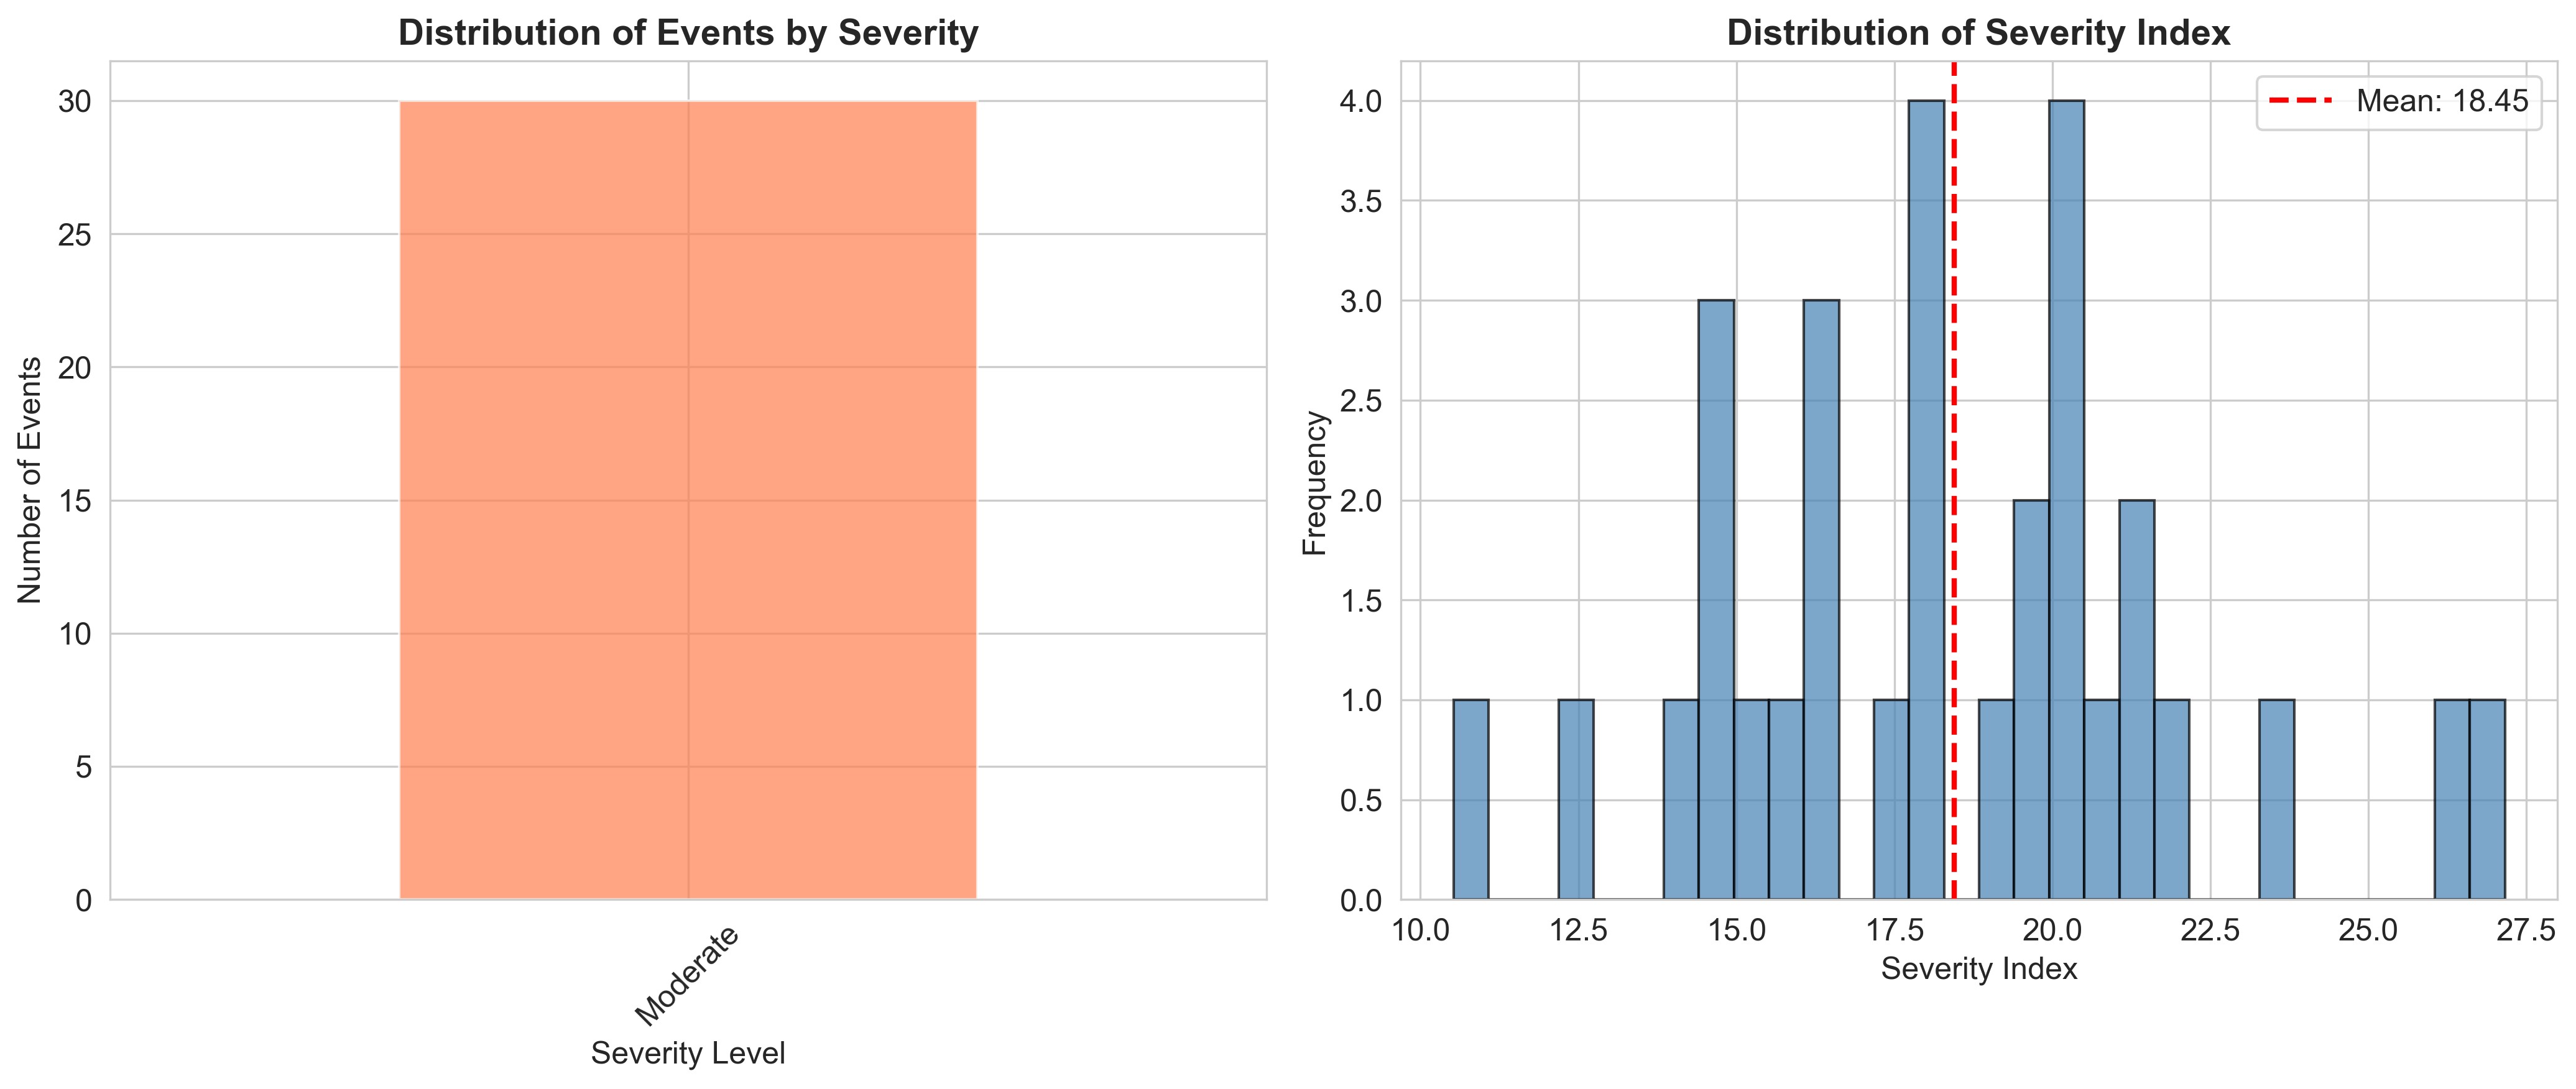

In [4]:
if df is not None:
    # Calculate severity index for each event
    df['severity_index'] = df.apply(
        lambda row: calculate_severity_index(
            deaths=row.get('total_deaths', 0),
            affected=row.get('total_affected', 0),
            damage=row.get('total_damage', 0)
        ), axis=1
    )
    
    # Classify severity
    df['severity_class'] = df['severity_index'].apply(classify_event_severity)
    
    print("Severity Classification Results:")
    print("="*60)
    severity_counts = df['severity_class'].value_counts()
    print("\nEvents by Severity Level:")
    for severity in ['Minor', 'Moderate', 'Severe', 'Catastrophic']:
        count = severity_counts.get(severity, 0)
        pct = (count / len(df)) * 100
        print(f"  {severity}: {count} ({pct:.1f}%)")
    
    # Visualize severity distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Bar chart
    severity_counts.plot(kind='bar', ax=ax1, color='coral', alpha=0.7)
    ax1.set_xlabel('Severity Level', fontsize=12)
    ax1.set_ylabel('Number of Events', fontsize=12)
    ax1.set_title('Distribution of Events by Severity', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    
    # Histogram of severity index
    ax2.hist(df['severity_index'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Severity Index', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Severity Index', fontsize=14, fontweight='bold')
    ax2.axvline(df['severity_index'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {df['severity_index'].mean():.2f}")
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_severity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4. Extreme Events Identification

In [5]:
if df is not None:
    # Identify top 10 most severe events
    top_severe = df.nlargest(10, 'severity_index')[[
        'year', 'hazardtype', 'level2', 'total_deaths', 'total_affected', 
        'usdvalue', 'severity_index', 'severity_class'
    ]]
    
    print("Top 10 Most Severe Events:")
    print("="*60)
    display(top_severe)
    
    # Identify catastrophic events
    catastrophic = df[df['severity_class'] == 'Catastrophic']
    print(f"\n⚠️  Catastrophic Events: {len(catastrophic)}")
    if len(catastrophic) > 0:
        print("\nCatastrophic Event Details:")
        display(catastrophic[['year', 'hazardtype', 'level2', 'total_deaths', 
                              'total_affected', 'usdvalue', 'severity_index']])

Top 10 Most Severe Events:


,year,hazardtype,level2,total_deaths,total_affected,usdvalue,severity_index,severity_class
26,2011,DROUGHT,Lower Shabelle,4120,1136000,14400000,27.158081,Moderate
16,2016,DROUGHT,Bay,2801,1553900,106800000,26.524476,Moderate
1,2023,DROUGHT,Somali,1019,338450,30000000,23.337245,Moderate
22,2013,FLOOD,Nyanza,690,113200,6720000,21.778166,Moderate
4,2022,DROUGHT,Banadir,312,1200000,4200000,21.596494,Moderate
6,2021,FLOOD,Western,279,1125200,14400000,21.312635,Moderate
24,2012,DROUGHT,North Eastern,279,570345,1440000,20.869998,Moderate
12,2018,DROUGHT,Eastern,205,890000,2760000,20.493422,Moderate
20,2014,FLOOD,Morogoro,279,301890,5400000,20.455565,Moderate
3,2022,FLOOD,Rift Valley,190,575890,9600000,20.045677,Moderate



⚠️  Catastrophic Events: 0


## 5. Severity by Hazard Type

Severity Analysis by Hazard Type:


,severity_index_mean,severity_index_median,severity_index_max,total_deaths_sum,total_affected_sum
hazardtype,,,,,
DROUGHT,22.85,21.60,27.16,8914,6358695
FLOOD,19.22,19.92,21.78,2287,4485701
EPIDEMIC,17.52,17.52,17.52,128,44130
LANDSLIDE,16.86,16.86,17.79,225,61990
STORM,15.26,14.71,17.84,221,569802
EARTHQUAKE,15.15,15.15,15.15,39,57189
HEAVY RAIN,14.53,14.53,14.53,26,82123
FIRE,12.41,12.41,14.30,47,22479


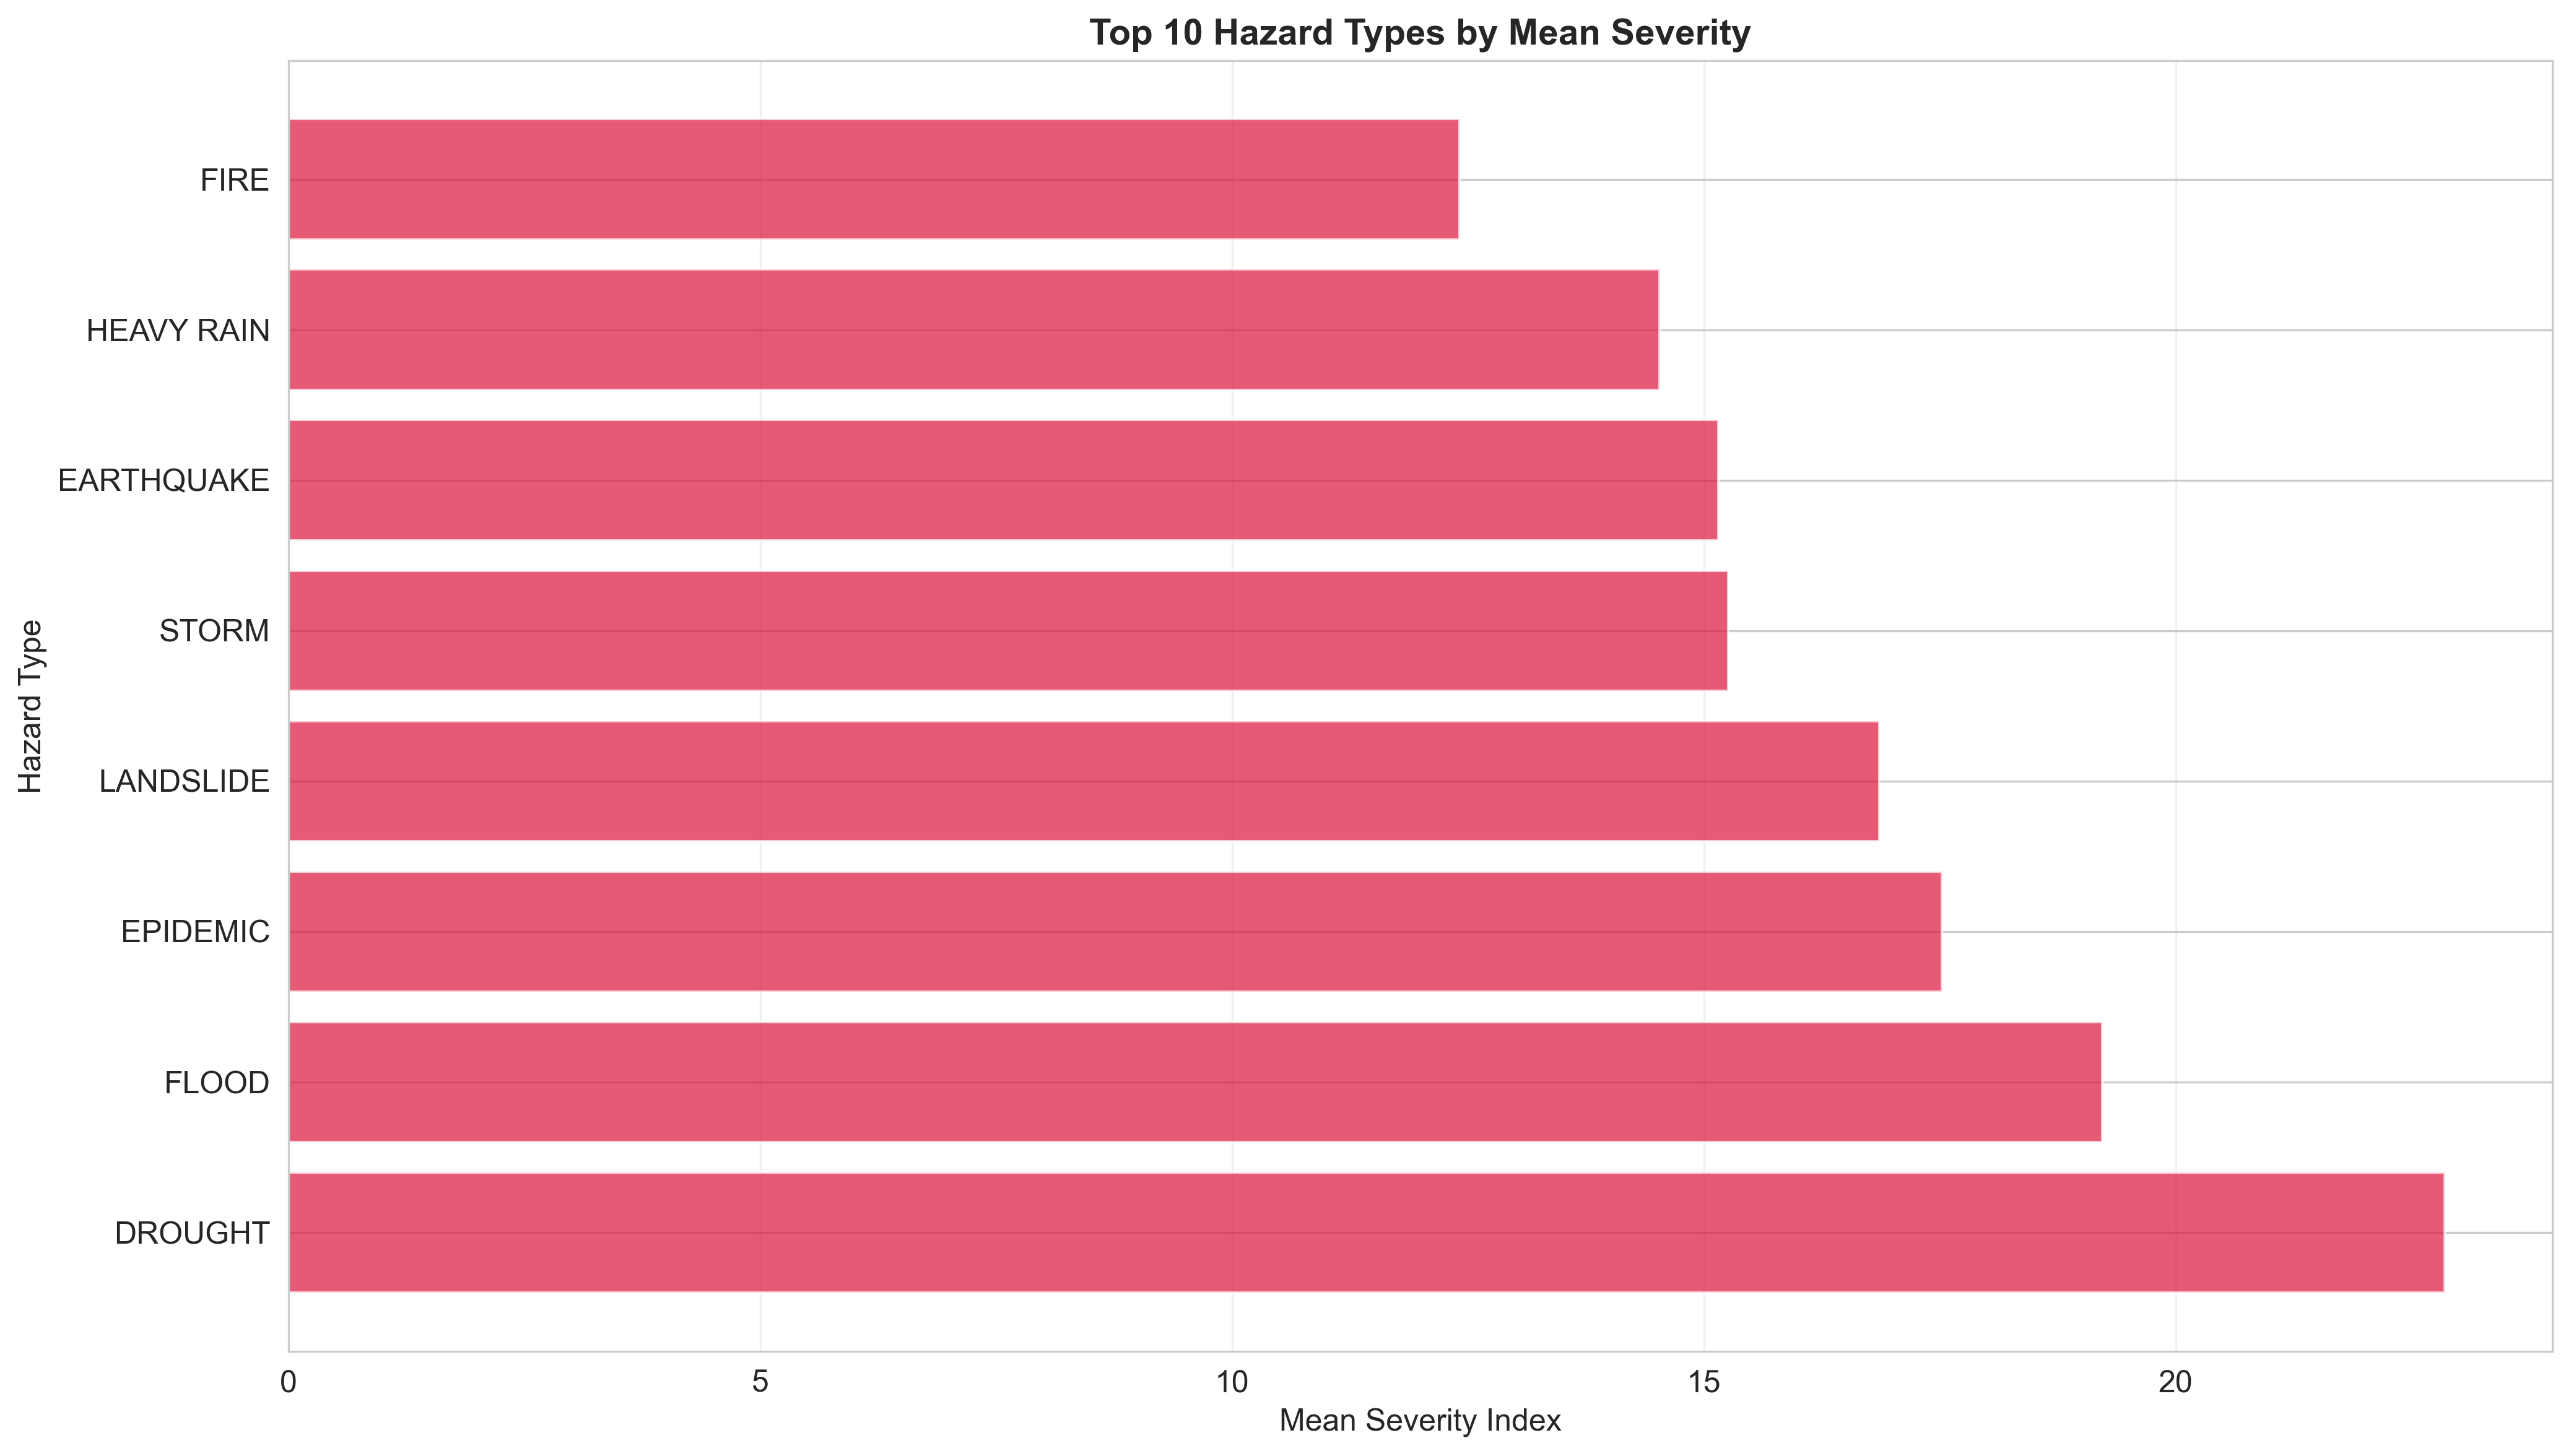

In [6]:
if df is not None and 'hazardtype' in df.columns:
    # Average severity by hazard type
    hazard_severity = df.groupby('hazardtype').agg({
        'severity_index': ['mean', 'median', 'max'],
        'total_deaths': 'sum',
        'total_affected': 'sum'
    }).round(2)
    
    hazard_severity.columns = ['_'.join(col).strip() for col in hazard_severity.columns.values]
    hazard_severity = hazard_severity.sort_values('severity_index_mean', ascending=False)
    
    print("Severity Analysis by Hazard Type:")
    print("="*60)
    display(hazard_severity.head(10))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 8))
    top_hazards = hazard_severity.head(10)
    ax.barh(range(len(top_hazards)), top_hazards['severity_index_mean'], color='crimson', alpha=0.7)
    ax.set_yticks(range(len(top_hazards)))
    ax.set_yticklabels(top_hazards.index)
    ax.set_xlabel('Mean Severity Index', fontsize=12)
    ax.set_ylabel('Hazard Type', fontsize=12)
    ax.set_title('Top 10 Hazard Types by Mean Severity', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_severity_by_hazard.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Impact Distribution Analysis

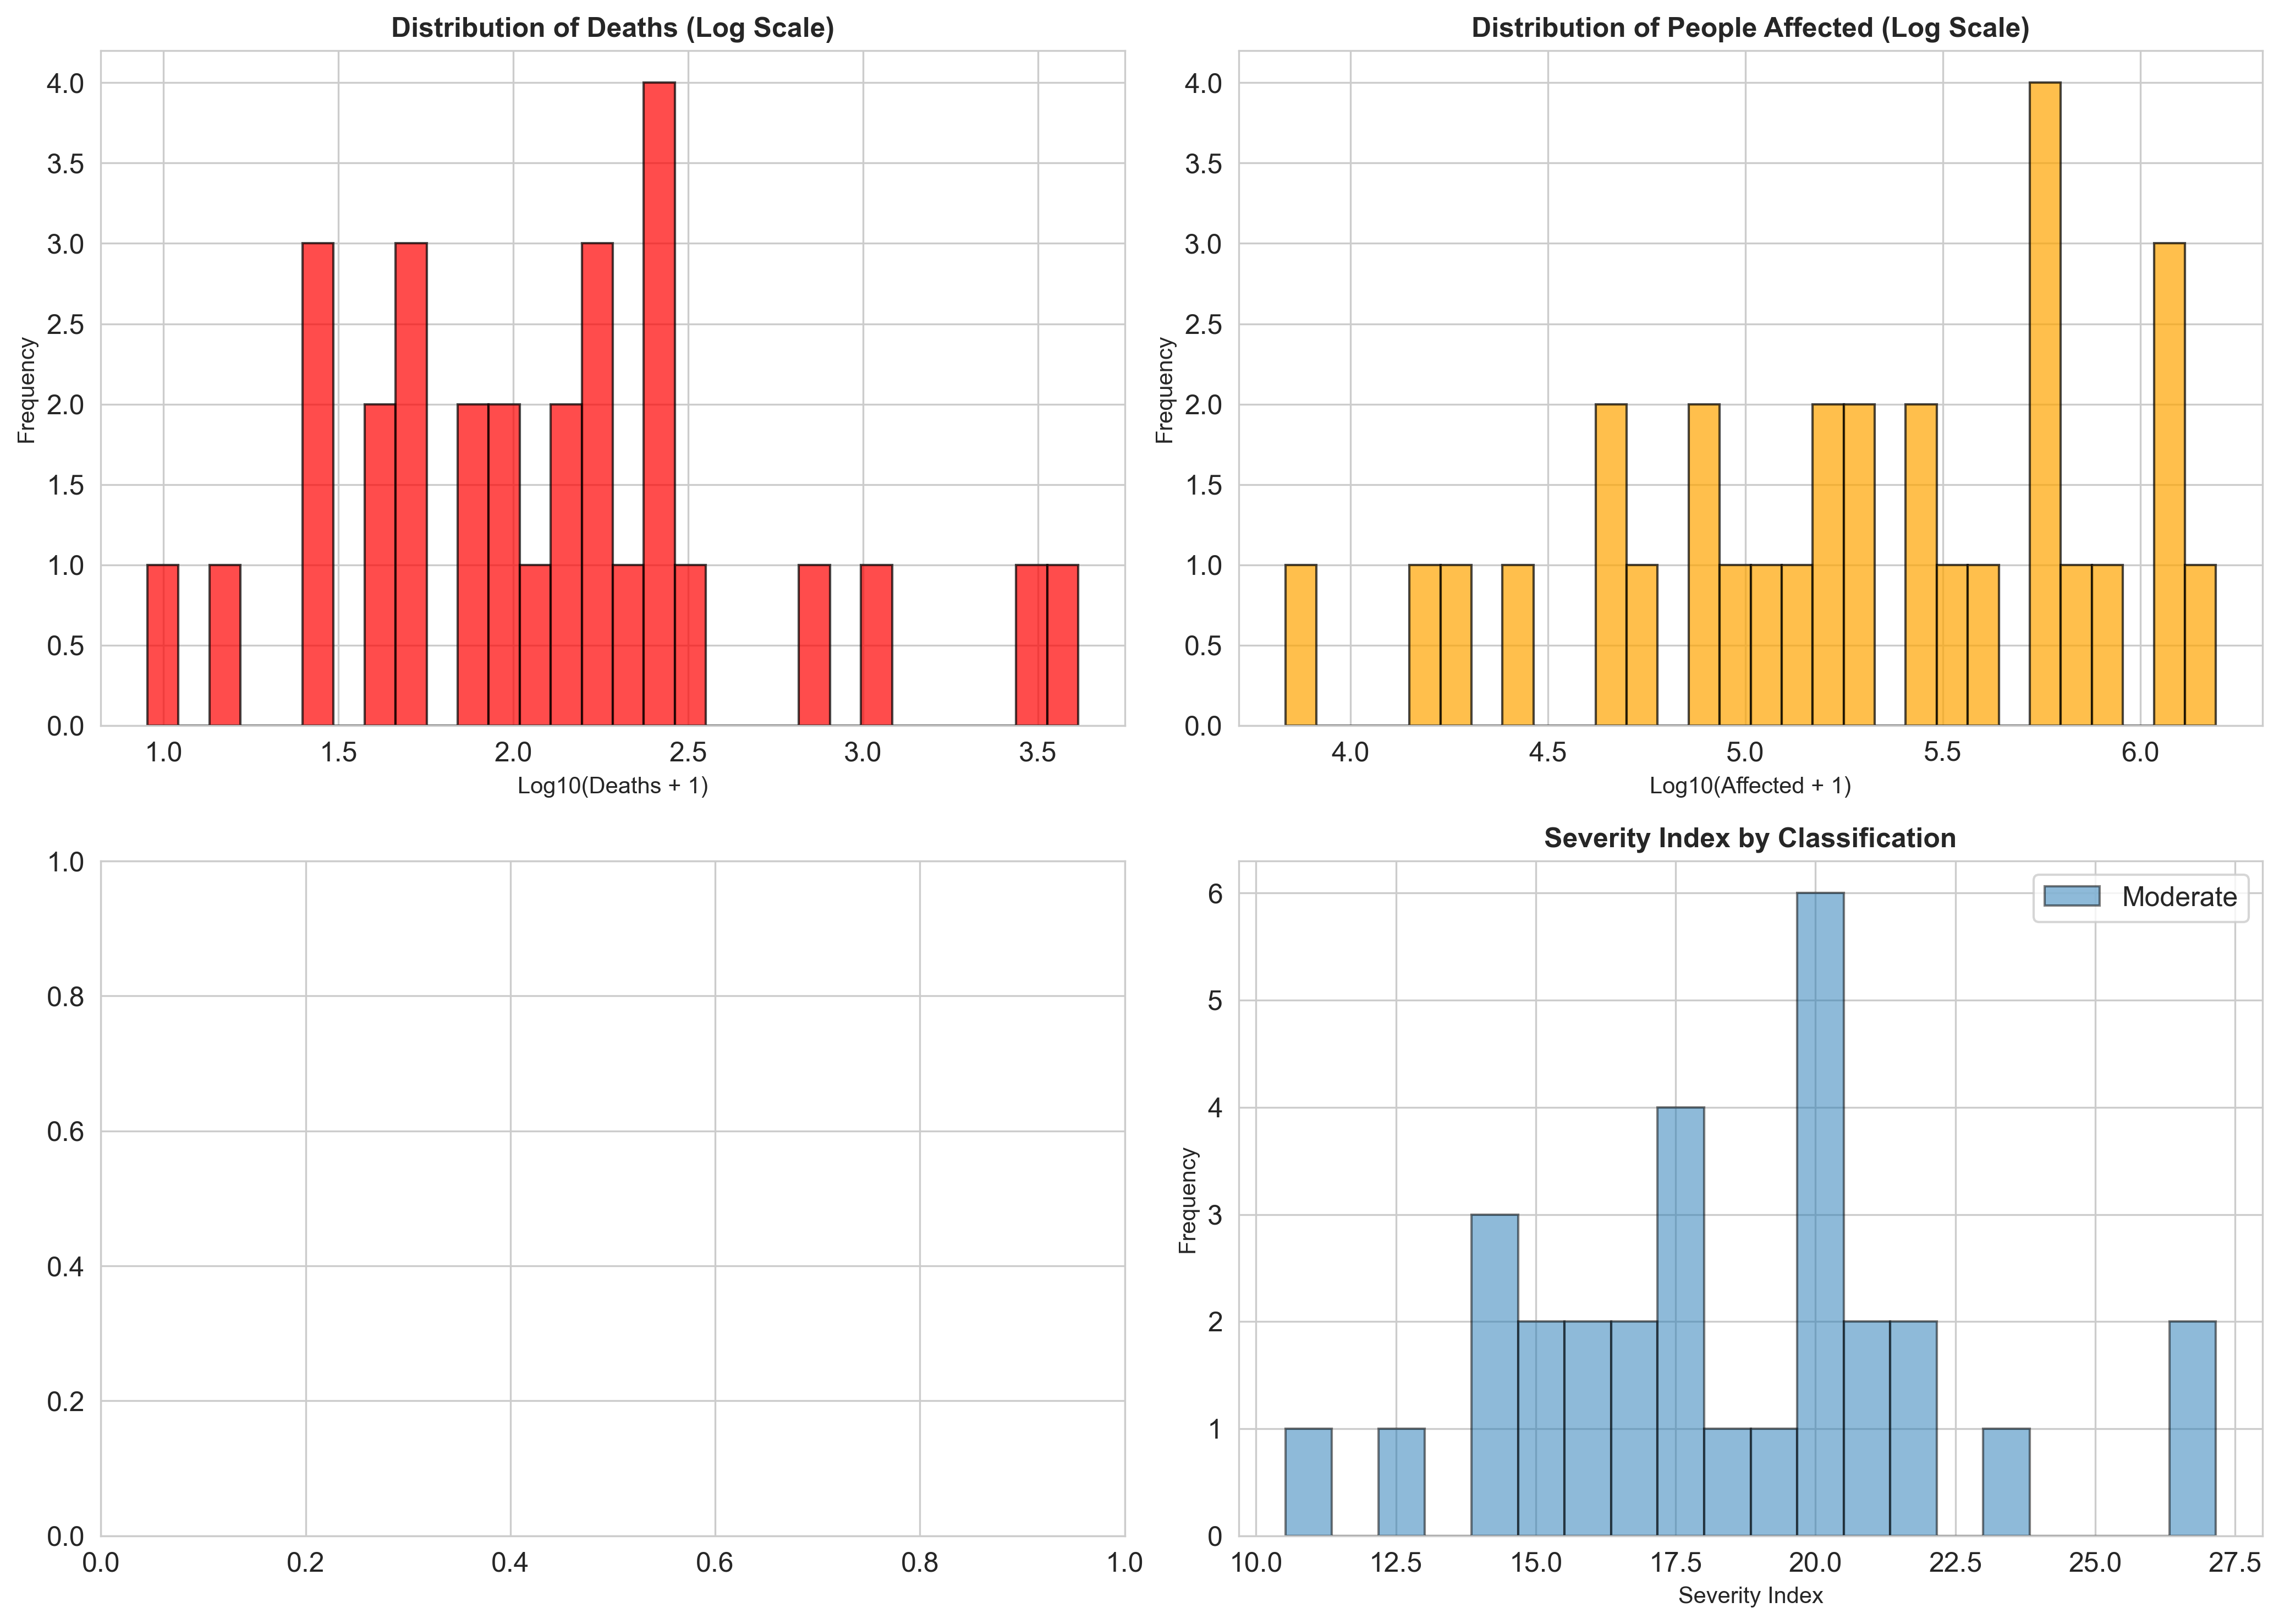

In [7]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Deaths distribution
    if 'total_deaths' in df.columns:
        deaths_nonzero = df[df['total_deaths'] > 0]['total_deaths']
        axes[0, 0].hist(np.log10(deaths_nonzero + 1), bins=30, color='red', alpha=0.7, edgecolor='black')
        axes[0, 0].set_xlabel('Log10(Deaths + 1)', fontsize=10)
        axes[0, 0].set_ylabel('Frequency', fontsize=10)
        axes[0, 0].set_title('Distribution of Deaths (Log Scale)', fontsize=12, fontweight='bold')
    
    # Affected distribution
    if 'total_affected' in df.columns:
        affected_nonzero = df[df['total_affected'] > 0]['total_affected']
        axes[0, 1].hist(np.log10(affected_nonzero + 1), bins=30, color='orange', alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel('Log10(Affected + 1)', fontsize=10)
        axes[0, 1].set_ylabel('Frequency', fontsize=10)
        axes[0, 1].set_title('Distribution of People Affected (Log Scale)', fontsize=12, fontweight='bold')
    
    # Damage distribution
    if 'total_damage' in df.columns:
        damage_nonzero = df[df['total_damage'] > 0]['total_damage']
        axes[1, 0].hist(np.log10(damage_nonzero + 1), bins=30, color='green', alpha=0.7, edgecolor='black')
        axes[1, 0].set_xlabel('Log10(Damage USD + 1)', fontsize=10)
        axes[1, 0].set_ylabel('Frequency', fontsize=10)
        axes[1, 0].set_title('Distribution of Economic Damage (Log Scale)', fontsize=12, fontweight='bold')
    
    # Severity index distribution by class
    for severity_class in df['severity_class'].unique():
        subset = df[df['severity_class'] == severity_class]['severity_index']
        axes[1, 1].hist(subset, bins=20, alpha=0.5, label=severity_class, edgecolor='black')
    axes[1, 1].set_xlabel('Severity Index', fontsize=10)
    axes[1, 1].set_ylabel('Frequency', fontsize=10)
    axes[1, 1].set_title('Severity Index by Classification', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_impact_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Geographic Severity Analysis

Top 15 Locations by Mean Severity:


,severity_index_mean,severity_index_max,severity_index_count,total_deaths_sum,total_affected_sum
level2,,,,,
Lower Shabelle,27.16,27.16,1,4120,1136000
Bay,26.52,26.52,1,2801,1553900
Somali,23.34,23.34,1,1019,338450
Nyanza,21.78,21.78,1,690,113200
Banadir,21.60,21.60,1,312,1200000
North Eastern,20.87,20.87,1,279,570345
Morogoro,20.46,20.46,1,279,301890
Oromia,20.00,20.00,1,178,670000
Addis Ababa,19.92,19.92,1,279,132467


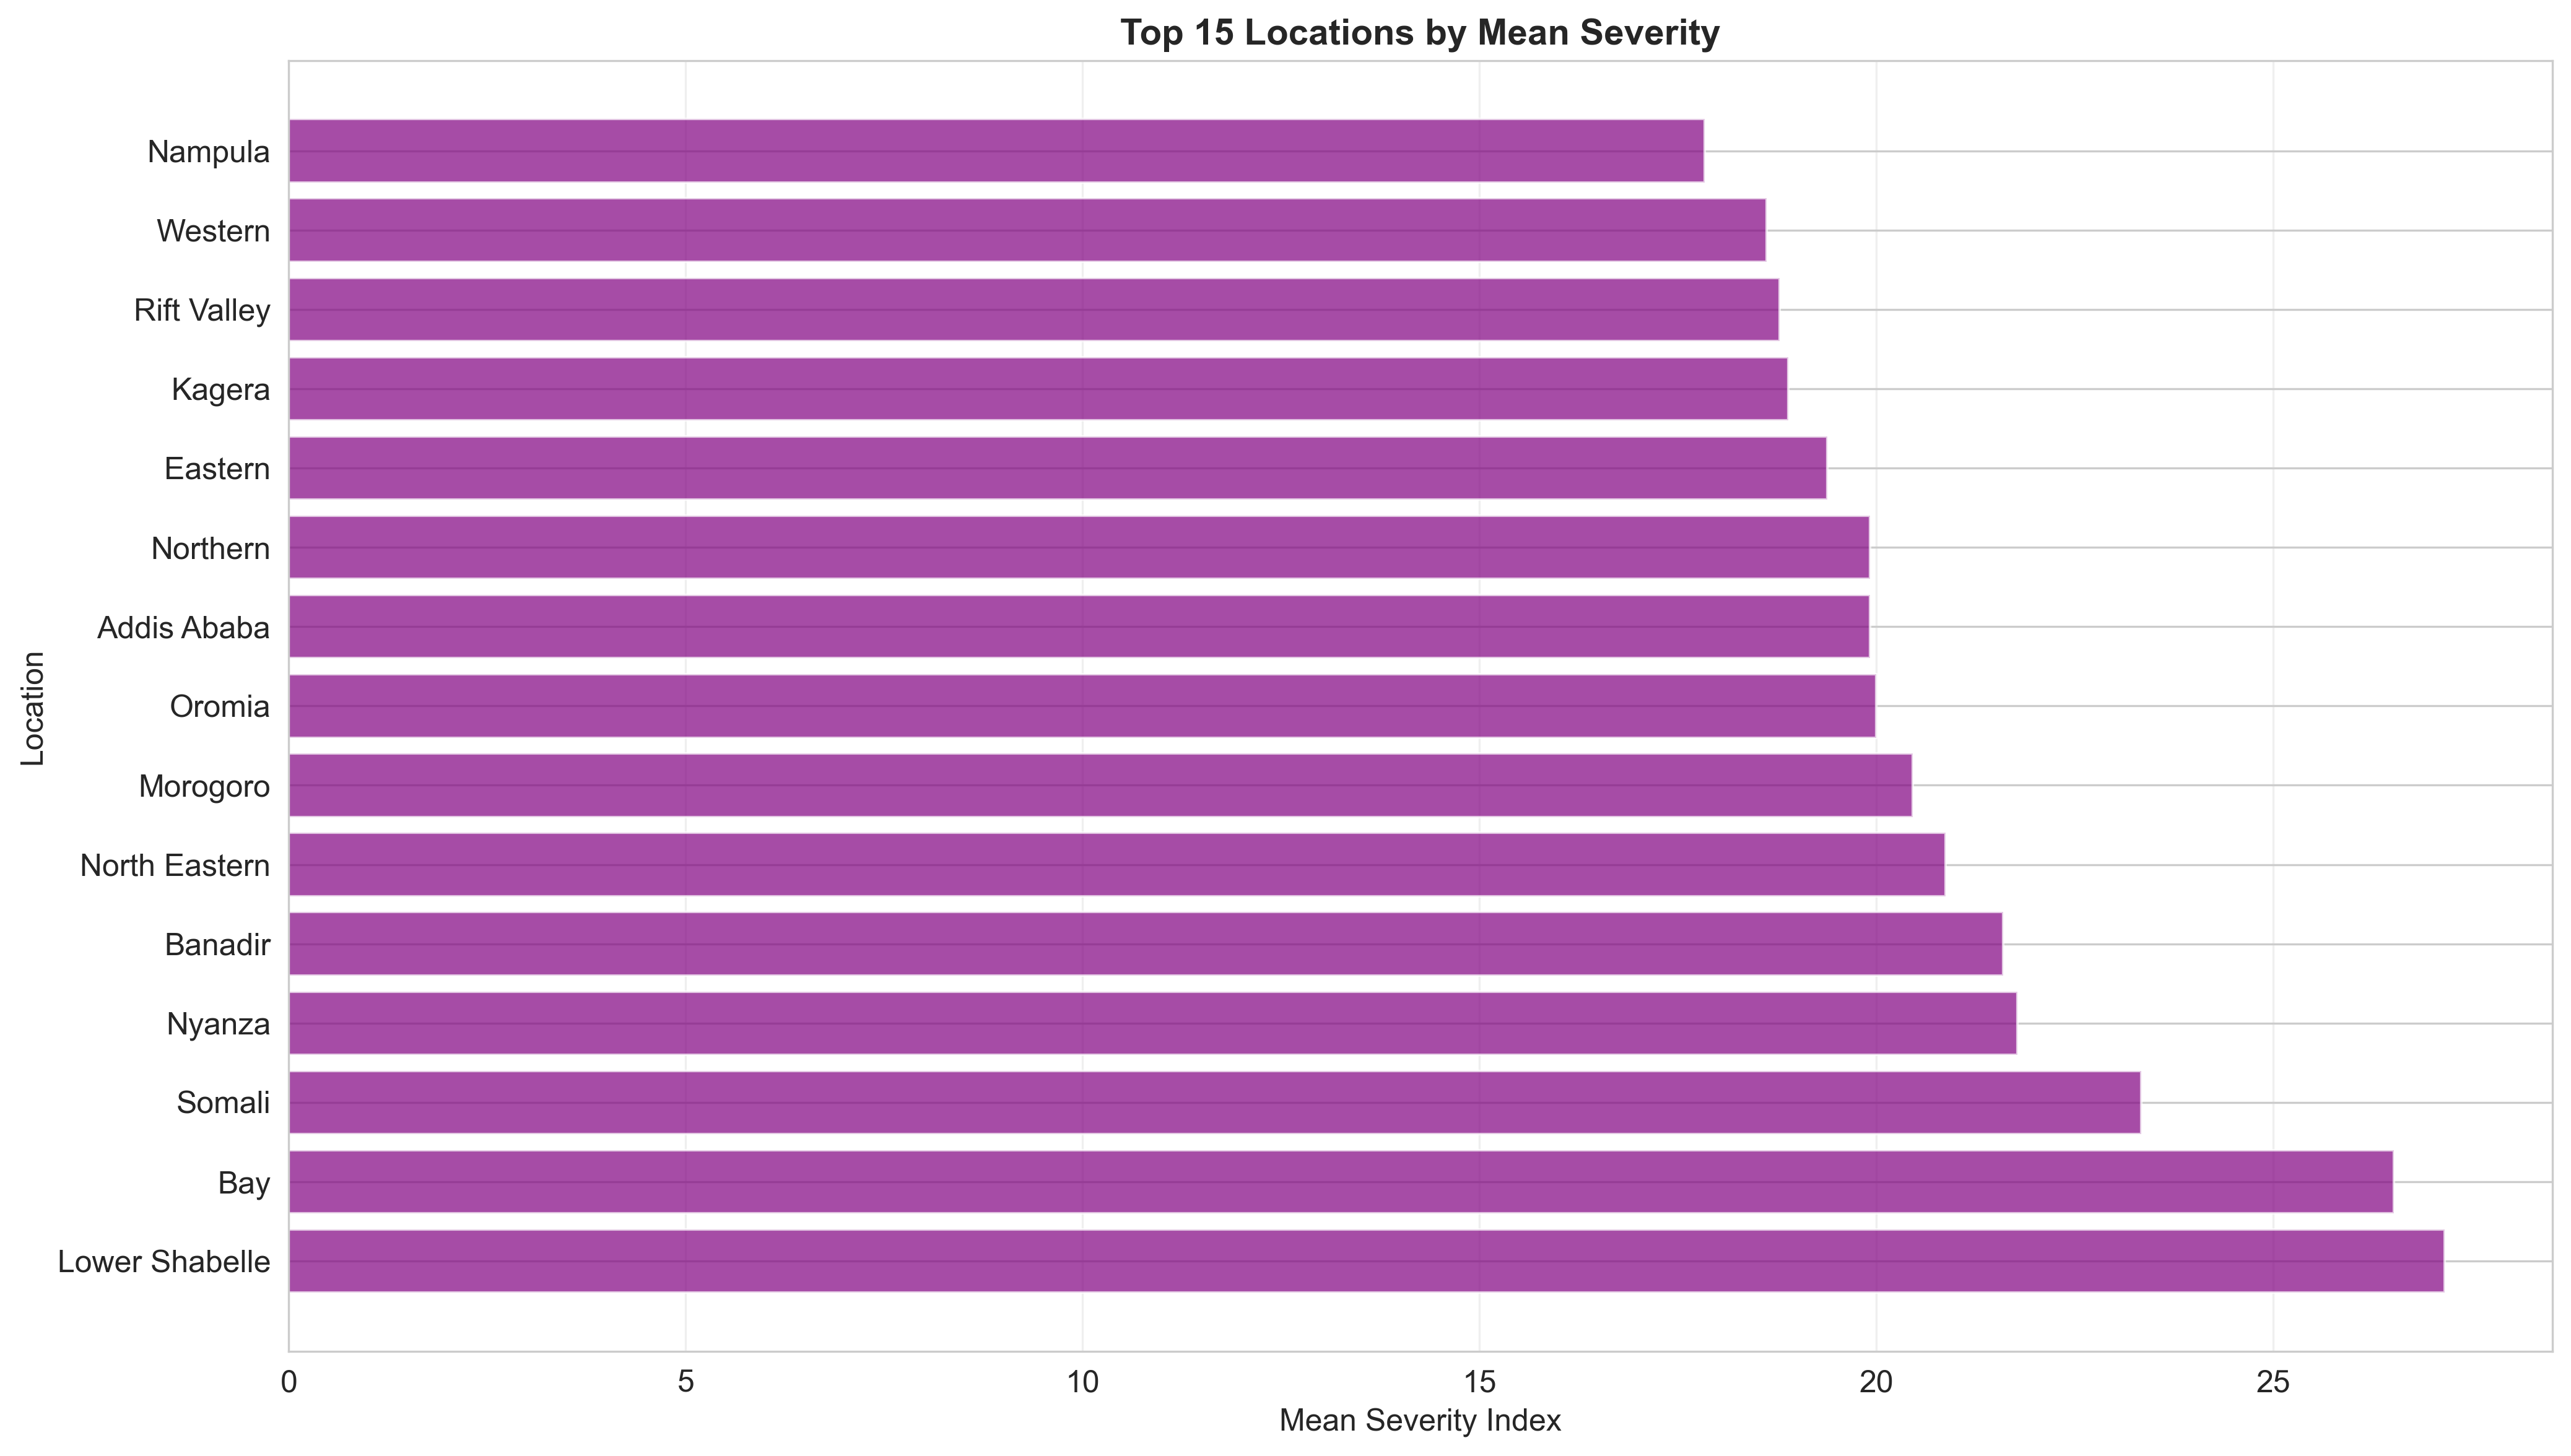

In [8]:
if df is not None and 'level2' in df.columns:
    location_severity = df.groupby('level2').agg({
        'severity_index': ['mean', 'max', 'count'],
        'total_deaths': 'sum',
        'total_affected': 'sum'
    }).round(2)
    
    location_severity.columns = ['_'.join(col).strip() for col in location_severity.columns.values]
    location_severity = location_severity.sort_values('severity_index_mean', ascending=False).head(15)
    
    print("Top 15 Locations by Mean Severity:")
    display(location_severity)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.barh(range(len(location_severity)), location_severity['severity_index_mean'], 
            color='purple', alpha=0.7)
    ax.set_yticks(range(len(location_severity)))
    ax.set_yticklabels(location_severity.index)
    ax.set_xlabel('Mean Severity Index', fontsize=12)
    ax.set_ylabel('Location', fontsize=12)
    ax.set_title('Top 15 Locations by Mean Severity', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_severity_by_location.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Temporal Trends in Severity

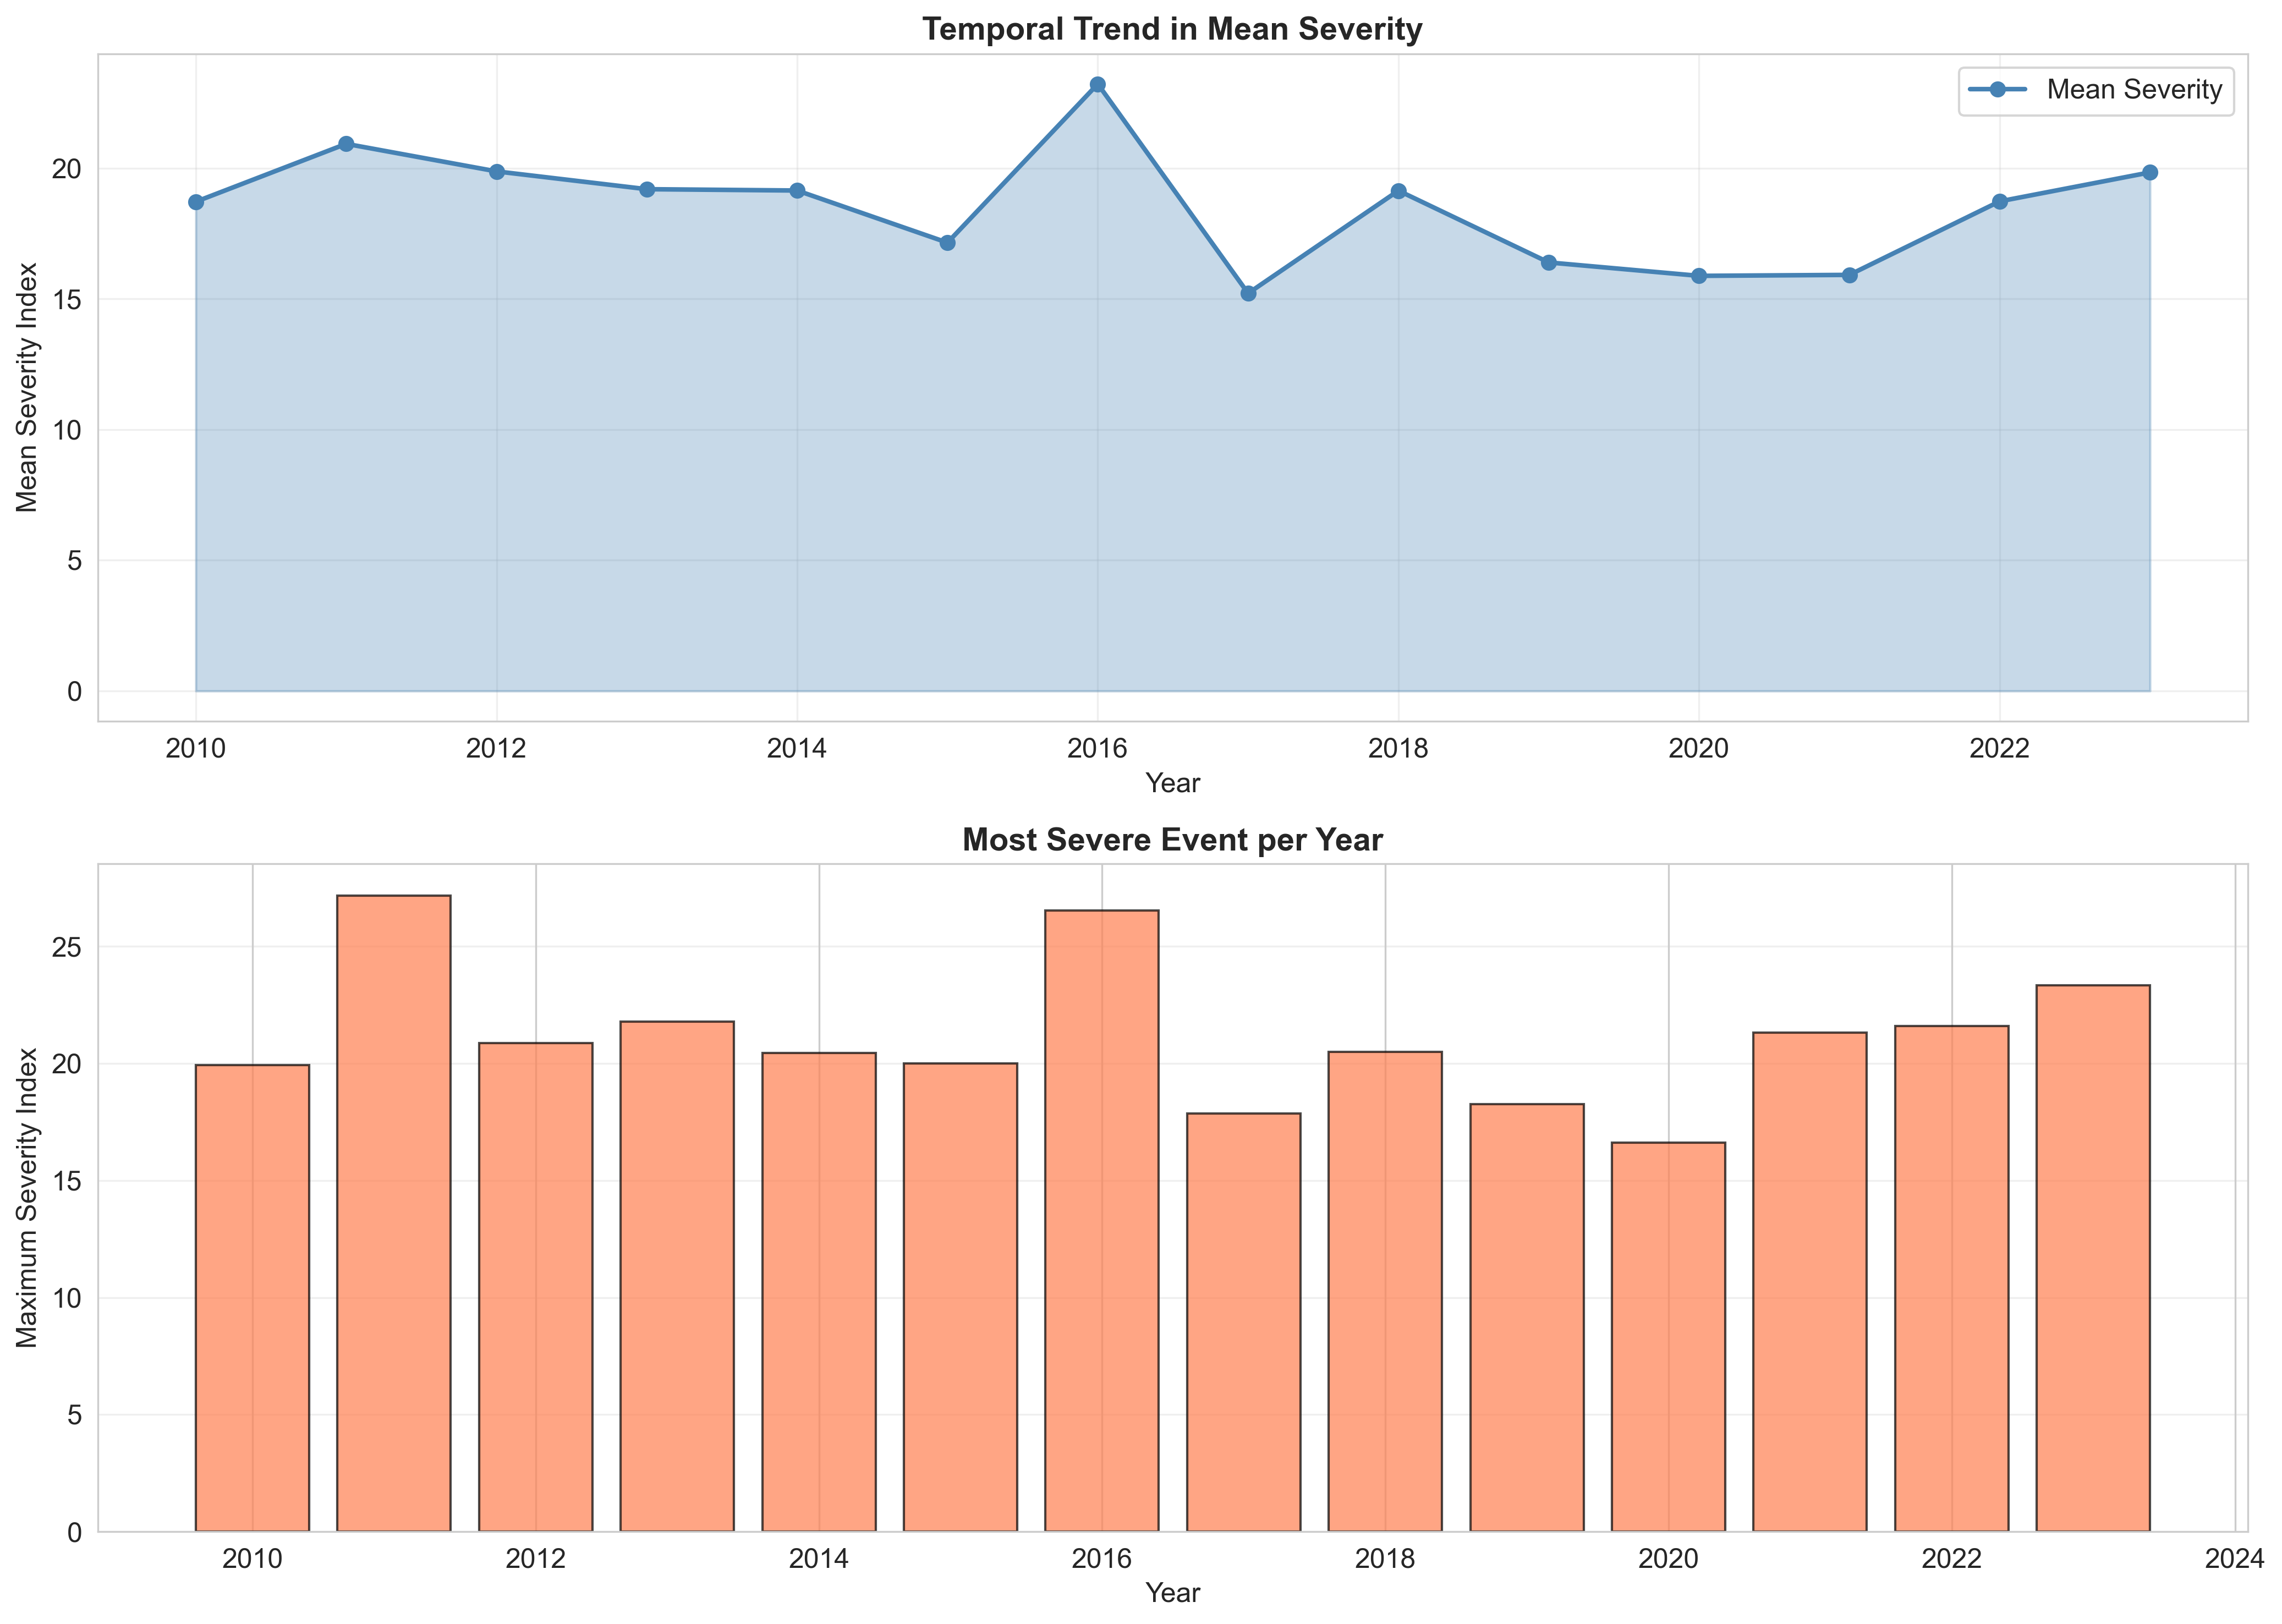

In [9]:
if df is not None and 'year' in df.columns:
    yearly_severity = df.groupby('year').agg({
        'severity_index': ['mean', 'max'],
        'total_deaths': 'sum',
        'total_affected': 'sum'
    }).reset_index()
    
    yearly_severity.columns = ['_'.join(col).strip() if col[1] else col[0] 
                                for col in yearly_severity.columns.values]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Mean severity over time
    ax1.plot(yearly_severity['year'], yearly_severity['severity_index_mean'], 
             marker='o', linewidth=2, color='steelblue', label='Mean Severity')
    ax1.fill_between(yearly_severity['year'], yearly_severity['severity_index_mean'], 
                      alpha=0.3, color='steelblue')
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Mean Severity Index', fontsize=12)
    ax1.set_title('Temporal Trend in Mean Severity', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Max severity over time
    ax2.bar(yearly_severity['year'], yearly_severity['severity_index_max'], 
            color='coral', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Maximum Severity Index', fontsize=12)
    ax2.set_title('Most Severe Event per Year', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_severity_temporal_trends.png', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Summary and Key Findings

In [10]:
if df is not None:
    print("="*80)
    print("SEVERITY ANALYSIS SUMMARY")
    print("="*80)
    
    print("\n📊 Overall Impact:")
    if 'total_deaths' in df.columns:
        print(f"   - Total Deaths: {df['total_deaths'].sum():,.0f}")
    if 'total_affected' in df.columns:
        print(f"   - Total People Affected: {df['total_affected'].sum():,.0f}")
    if 'total_damage' in df.columns:
        print(f"   - Total Economic Damage: ${df['total_damage'].sum():,.0f}")
    
    print("\n⚠️  Severity Distribution:")
    severity_pct = (df['severity_class'].value_counts() / len(df) * 100).round(1)
    for severity in ['Minor', 'Moderate', 'Severe', 'Catastrophic']:
        if severity in severity_pct.index:
            print(f"   - {severity}: {severity_pct[severity]}%")
    
    if 'hazardtype' in df.columns:
        most_severe_hazard = df.groupby('hazardtype')['severity_index'].mean().idxmax()
        print(f"\n🔥 Most Severe Hazard Type:")
        print(f"   - {most_severe_hazard}")
    
    if 'level2' in df.columns:
        most_severe_location = df.groupby('level2')['severity_index'].mean().idxmax()
        print(f"\n📍 Most Severely Affected Location:")
        print(f"   - {most_severe_location}")
    
    print("\n📈 Next Steps:")
    print("   1. Proceed to risk assessment (notebook 04)")
    print("   2. Combine frequency and severity for comprehensive risk analysis")
    print("   3. Identify high-risk areas requiring priority intervention")

SEVERITY ANALYSIS SUMMARY

📊 Overall Impact:
   - Total Deaths: 11,887
   - Total People Affected: 11,682,109

⚠️  Severity Distribution:
   - Moderate: 100.0%

🔥 Most Severe Hazard Type:
   - DROUGHT

📍 Most Severely Affected Location:
   - Lower Shabelle

📈 Next Steps:
   1. Proceed to risk assessment (notebook 04)
   2. Combine frequency and severity for comprehensive risk analysis
   3. Identify high-risk areas requiring priority intervention


## 10. Save Enhanced Dataset

In [11]:
if df is not None:
    # Save dataset with severity metrics
    output_file = PROCESSED_DATA_DIR / 'disaster_events_with_severity.csv'
    df.to_csv(output_file, index=False)
    print(f"✅ Enhanced dataset saved to: {output_file}")
    print(f"   Added columns: severity_index, severity_class")

✅ Enhanced dataset saved to: D:\Projects\sendai-multi-hazard-risk-modeling\data\processed\disaster_events_with_severity.csv
   Added columns: severity_index, severity_class
